In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.filterwarnings('ignore')

In [57]:
plt.style.use('ggplot')

pd.set_option('display.max_columns', None)


In [58]:
Articles = pd.read_csv('../Data/articles.csv')
Customers = pd.read_csv('../Data/customers.csv')
Transactions = pd.read_csv('../Data/transactions_train.csv')

In [59]:
print("Articles:", articles.shape)
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Articles: (105542, 5)
Customers: (1371980, 7)
Transactions: (31788324, 4)


In [60]:
articles.info()

customers.info()

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   article_id         105542 non-null  int64
 1   prod_name          105542 non-null  str  
 2   product_type_name  105542 non-null  str  
 3   colour_group_name  105542 non-null  str  
 4   department_name    105542 non-null  str  
dtypes: int64(1), str(4)
memory usage: 8.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  str    
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  str    
 4   fashion_news_frequency  1355969 non-null  str    
 5   age                     1356119 non

# Missing Values

In [61]:
articles.isnull().sum().sort_values(ascending=False)

article_id           0
prod_name            0
product_type_name    0
colour_group_name    0
department_name      0
dtype: int64

In [62]:
customers.isnull().sum().sort_values(ascending=False)

Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64

In [63]:
transactions.isnull().sum()

customer_id    0
article_id     0
price          0
t_dat          0
dtype: int64

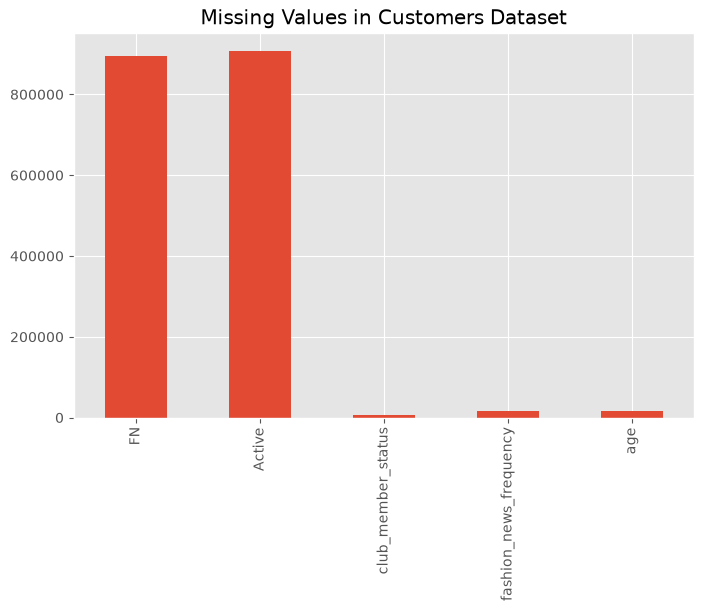

In [64]:
missing = customers.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))
missing.plot(kind='bar')
plt.title("Missing Values in Customers Dataset")
plt.show()

# Transactional Analysis

In [65]:
# Total Customers

transactions['customer_id'].nunique()

1362281

In [66]:
# Total Products

transactions['article_id'].nunique()

104547

In [67]:
# Total Transactions

len(transactions)

31788324

# Monthly Purchases Trends

In [68]:
transactions['t_dat'] = pd.to_datetime(
    transactions['t_dat']
)

transactions['month'] = (
    transactions['t_dat']
    .dt.to_period('M')
)

monthly_sales = (
    transactions
    .groupby('month')
    .size()
)

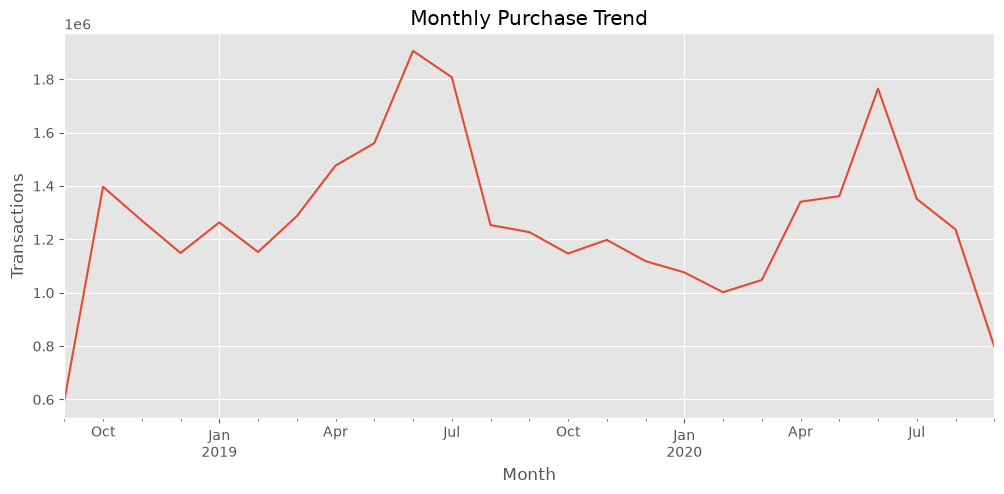

In [69]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.show()

From July to April the purchase is high

# Revenue Distribution

In [70]:
# price statistics
pd.set_option('display.float_format', '{:.6f}'.format)
transactions['price'].describe()

count   31788324.000000
mean           0.027829
std            0.019181
min            0.000017
25%            0.015814
50%            0.025407
75%            0.033881
max            0.591525
Name: price, dtype: float64

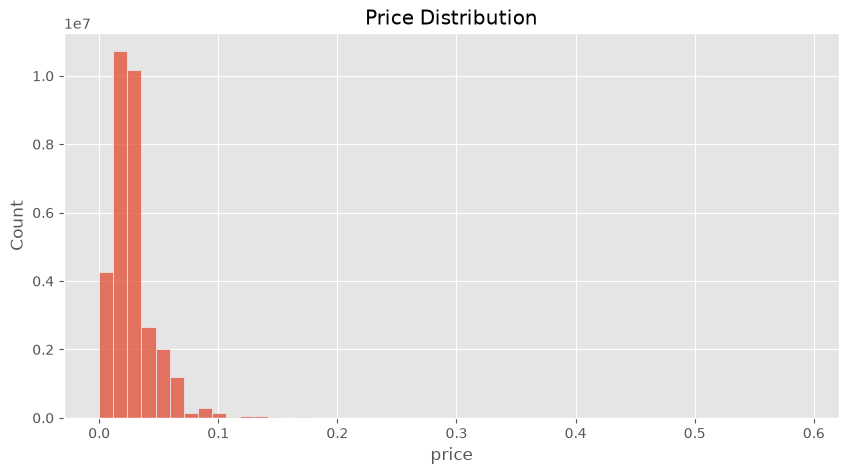

In [71]:
plt.figure(figsize=(10,5))

sns.histplot(
    transactions['price'],
    bins=50
)

plt.title("Price Distribution")

plt.show()

# Customer Purchasing Behavior

In [72]:
customer_orders = (
    transactions
    .groupby('customer_id')
    .size()
)

In [73]:
customer_orders.describe()

count   1362281.000000
mean         23.334631
std          39.242253
min           1.000000
25%           3.000000
50%           9.000000
75%          27.000000
max        1895.000000
dtype: float64

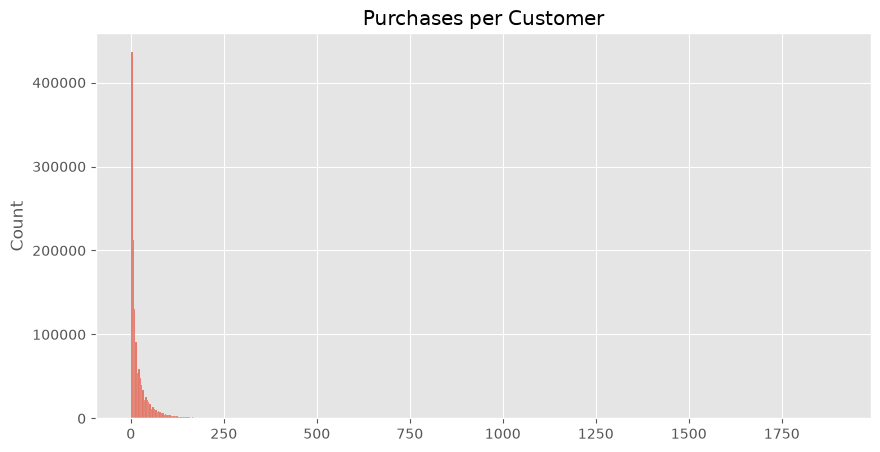

In [74]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_orders,
    bins=500
)

plt.title("Purchases per Customer")

plt.show()

Most of them are one time buyer

# Product Popularity Analysis

In [75]:
data = transactions.merge(
    articles,
    on='article_id',
    how='left'
)

In [76]:
top_products = (
    data['prod_name']
    .value_counts()
    .head(10)
)

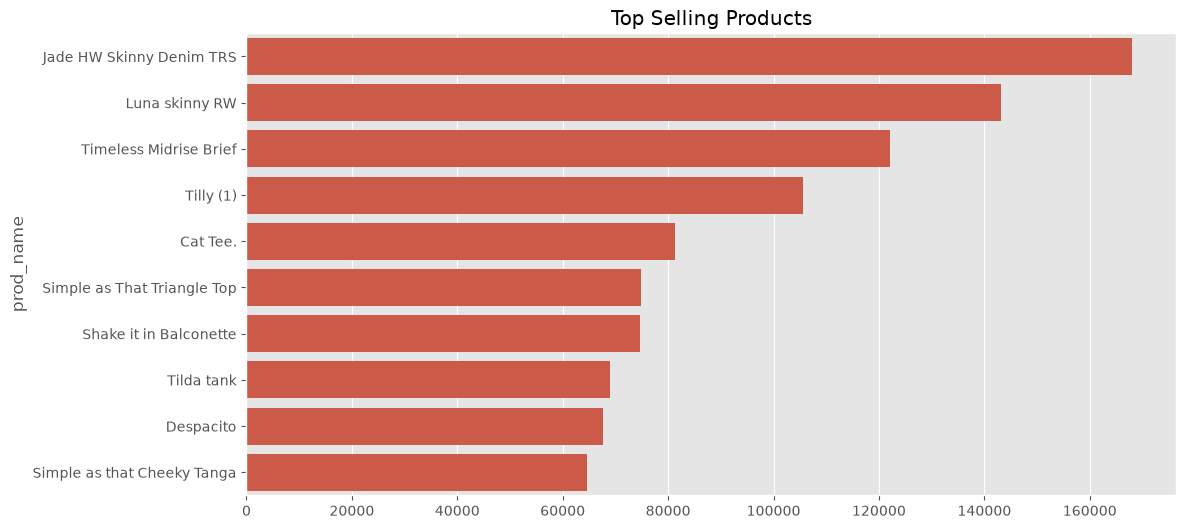

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Products")

plt.show()

This shows the majority of product purchases

# Product Category Analysis

In [78]:
category_counts = (
    data['product_type_name']
    .value_counts()
    .head(15)
)

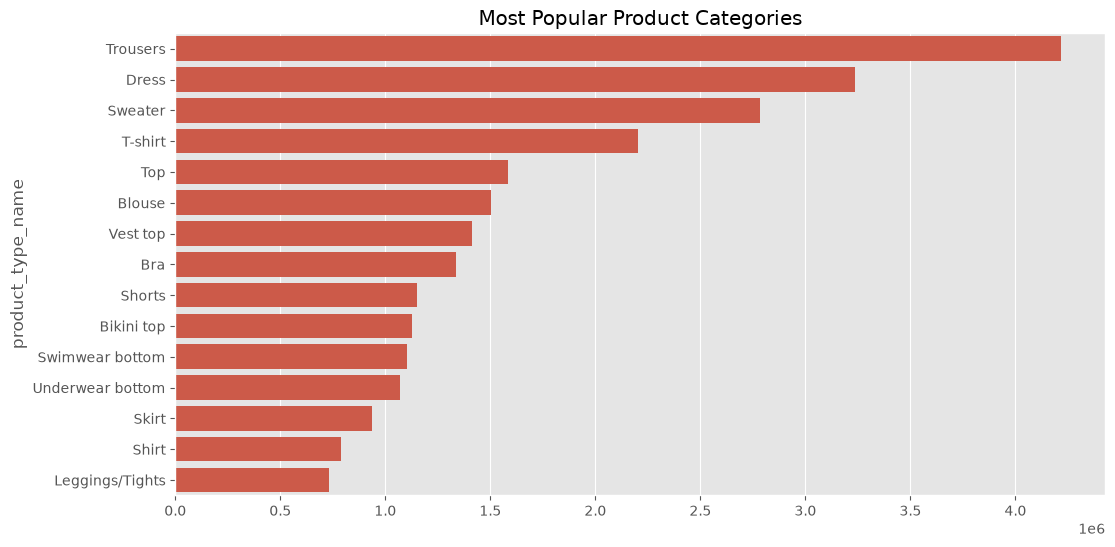

In [79]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Most Popular Product Categories")

plt.show()

Trousers are the most popular product

# Color Preferences

In [80]:
color_counts = (
    data['colour_group_name']
    .value_counts()
    .head(10)
)

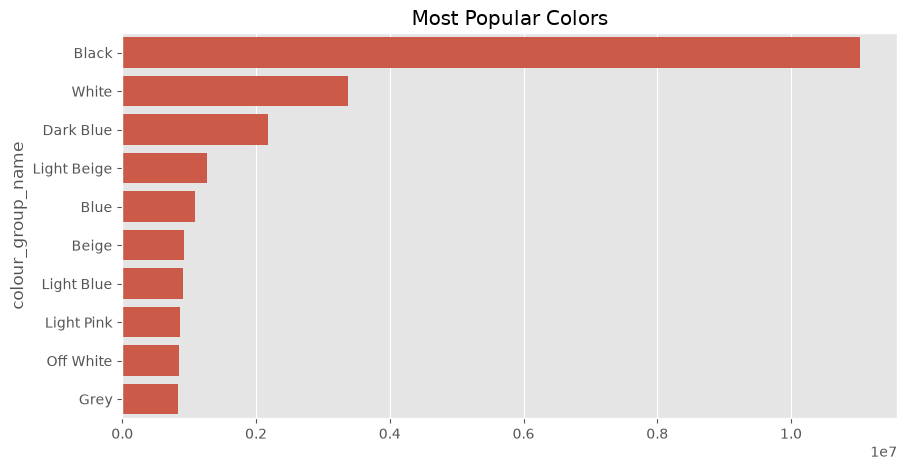

In [81]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=color_counts.values,
    y=color_counts.index
)

plt.title("Most Popular Colors")

plt.show()

Most customers have black color as ther preferences

# Department Analysis

In [82]:
dept_counts = (
    data['department_name']
    .value_counts()
    .head(15)
)

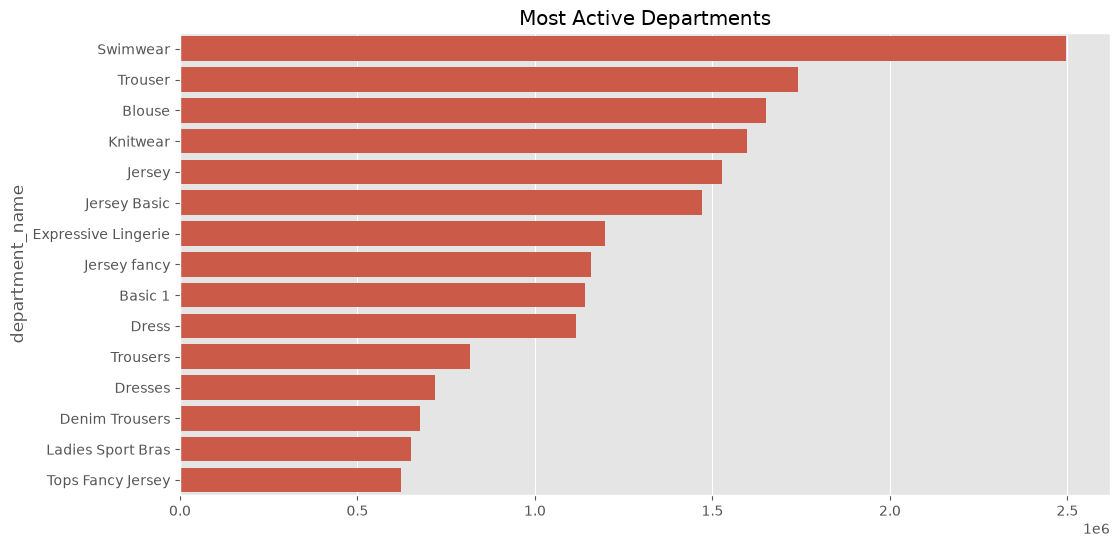

In [83]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=dept_counts.values,
    y=dept_counts.index
)

plt.title("Most Active Departments")

plt.show()

# Customer Age Analysis

In [84]:
data = data.merge(
    customers[['customer_id','age']],
    on='customer_id',
    how='left'
)

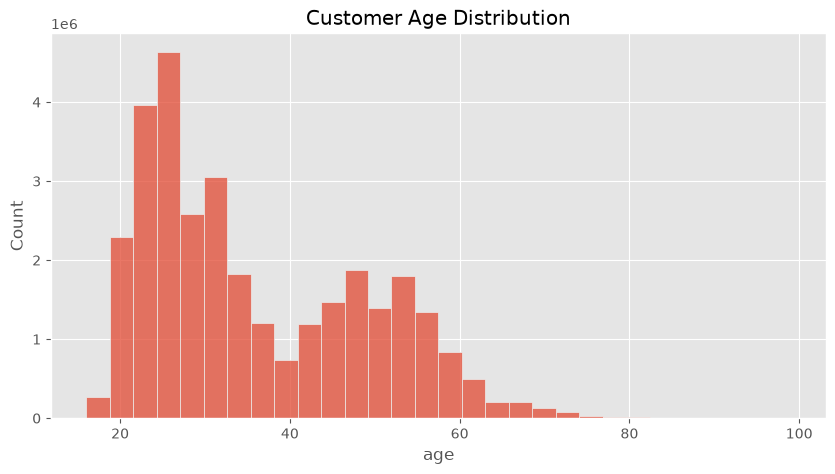

In [85]:
plt.figure(figsize=(10,5))

sns.histplot(
    data['age'],
    bins=30
)

plt.title("Customer Age Distribution")

plt.show()

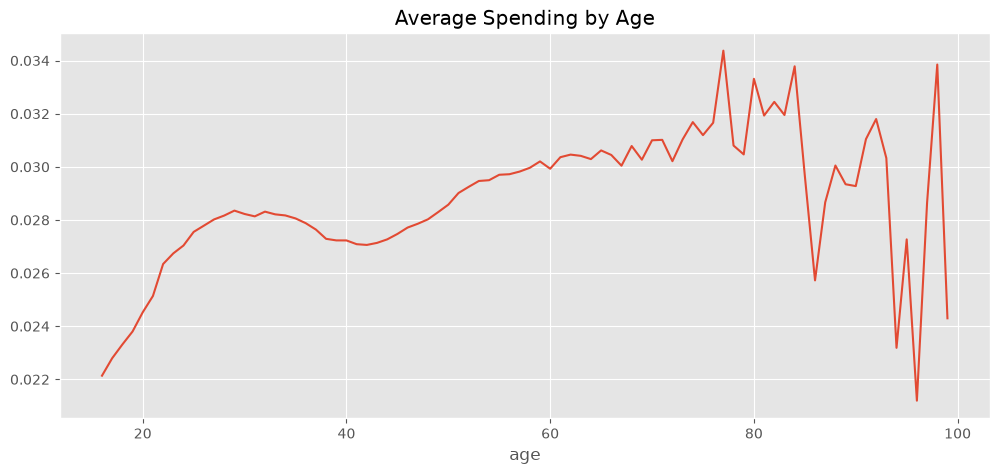

In [86]:
# Age vs Spending

age_spending = (
    data.groupby('age')['price']
    .mean()
)

plt.figure(figsize=(12,5))

age_spending.plot()

plt.title("Average Spending by Age")

plt.show()

Teens and Adults are the mainly custometrs

# Top Customers

In [87]:
top_customers = (
    transactions['customer_id']
    .value_counts()
    .head(10)
)

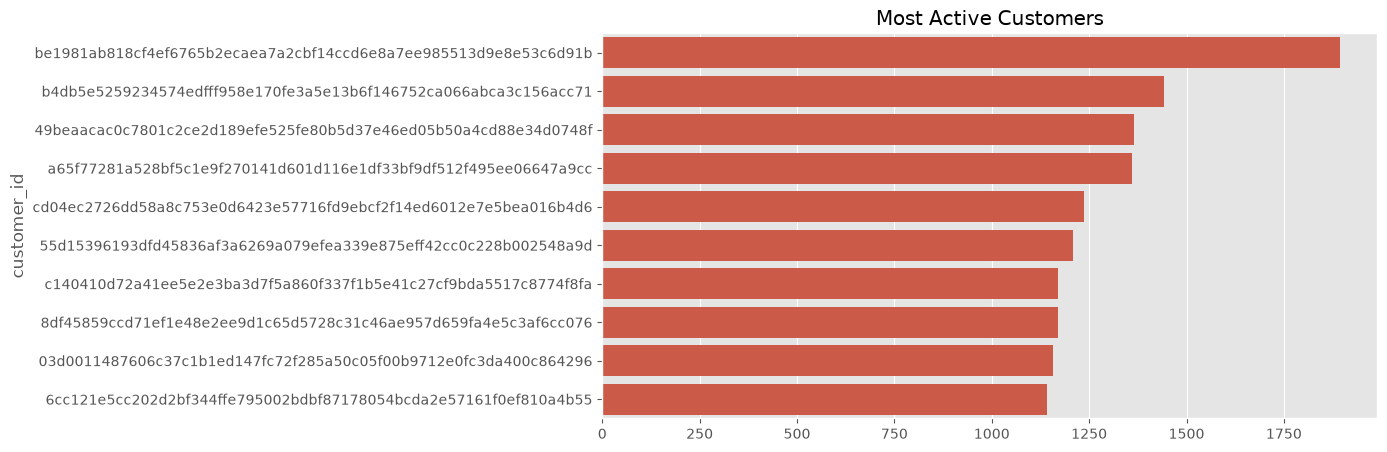

In [88]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Most Active Customers")

plt.show()

# RFM Analysis

- Recency
- Frequency
- Monetary

In [89]:
snapshot_date = transactions['t_dat'].max()

In [90]:
rfm = transactions.groupby('customer_id').agg({
    't_dat': lambda x: (snapshot_date - x.max()).days,
    'article_id': 'count',
    'price': 'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

# Correlation Heatmap

In [91]:
rfm.corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.358451,-0.330342
Frequency,-0.358451,1.000000,0.958672
Monetary,-0.330342,0.958672,1.000000


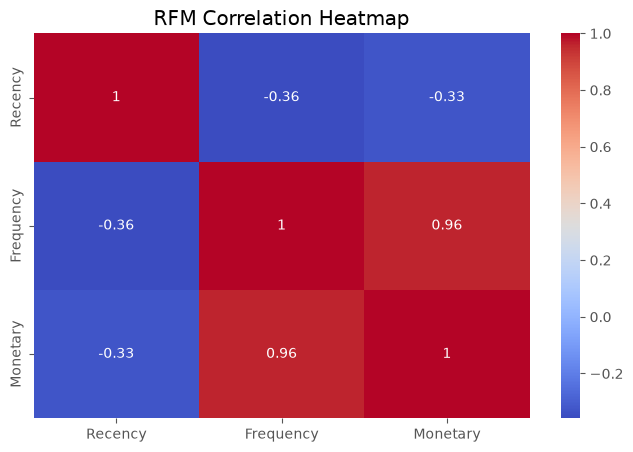

In [92]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("RFM Correlation Heatmap")

plt.show()